In [13]:
import os
import sys
import gc
import base64
import pickle
import itertools
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import tensorflow as tf
from cycler import cycler
from matplotlib.colors import to_hex

In [17]:
with open("/Users/kautsarg/Documents/Final Project/Run Data/POC_DDM_dataset/D20250826_E00_C00_F4500KHz_U_Sample_14_rep2/initial_kinetics_2.pkl", 'rb') as f:
    kinetics = pickle.load(f)


In [20]:
exp_root = "/Users/kautsarg/Documents/Final Project/Run Data/POC_DDM_dataset"
exp_folders = [name for name in os.listdir(exp_root) if (os.path.isdir(os.path.join(exp_root, name)) and name not in [".DS_Store"])]
exp_paths = [Path(exp_root, name) for name in exp_folders]

importance_dfs = {
    "dataset_name": [],
    "dataset": [],
    "Y_well": [],
    "timestamps": [],
    "importance_dfs": [],
    "top_combination": [],
}

for exp_path in exp_paths:
    importance_dfs_path = os.path.join(exp_path, "feature_importance_dfs.pkl")
    with open(importance_dfs_path, 'rb') as f:
        data = pickle.load(f)
    
    importance_dfs["dataset_name"].append(data["dataset_name"])
    importance_dfs["dataset"].append(data["dataset"])
    importance_dfs["Y_well"].append(data["Y_well"])
    importance_dfs["timestamps"].append(data["timestamps"])
    importance_dfs["importance_dfs"].append(data["importance_dfs"])
    importance_dfs["top_combination"].append(data["top_combination"])

dataset_name = importance_dfs["dataset_name"][0]

In [21]:
EXCLUDED_FEATURES = [
    'TH', 'msc_mahal_dist', 'msc_label_0.001', 'amf_label_Send', 
    'amf_label_Send_abs', 'amf_label_Send_fit', 'amf_label_Send_fit_abs', 
    'mean_std_outlier_label_3sigma',
    "pixel_row_idx", "pixel_col_idx", "temp_group_idx", "num_active_pixels_in_temp_group", "well_temp_lin2d_mean", "well_2d_temp_npr_mean"
]

In [22]:
dataset_name_sliced = [dname for dname in dataset_name if dname not in ["ori_curves_avg", "original_fitted_stretched"]]
feature_ranks = {}

for dname in dataset_name_sliced: feature_ranks[dname] = {} 

for i, folder in enumerate(exp_folders):
    # print("-"*50)
    # print(folder)
    # print("-"*50)
    feature_ranks[folder] = {}
    for j, dname in enumerate(dataset_name_sliced):
        ranked_features = [feature for feature in importance_dfs["importance_dfs"][i][j].feature.values if feature not in EXCLUDED_FEATURES]
        feature_ranks[dname][folder] = ranked_features
        # print(f"   > {dname}")
        # print(f"     {ranked_features}")

In [23]:
import pandas as pd
from functools import reduce

dataset_name_sliced = [dname for dname in dataset_name if dname not in ["ori_curves_avg", "original_fitted_stretched"]]

feature_summary_dfs = {}

for j, dname in enumerate(dataset_name_sliced):
    folder_dfs = []
    
    for i, folder in enumerate(exp_folders):
        df = importance_dfs["importance_dfs"][i][j].copy()
        df = df[~df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        rank_col = f"rank_{folder}"
        imp_col = f"importance_{folder}"
        
        df[rank_col] = df['importance'].rank(ascending=False, method='min')
        df = df.rename(columns={'importance': imp_col})
        
        folder_dfs.append(df[['feature', imp_col, rank_col]])
        
    merged_df = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), folder_dfs)
    
    importance_cols = [col for col in merged_df.columns if col.startswith('importance_')]
    rank_cols = [col for col in merged_df.columns if col.startswith('rank_')]
    
    merged_df = merged_df[['feature'] + importance_cols + rank_cols]
    
    merged_df['median_rank'] = merged_df[rank_cols].median(axis=1)
    merged_df = merged_df.sort_values('median_rank').reset_index(drop=True)
    
    feature_summary_dfs[dname] = merged_df

avg_rank_dfs = []
for dname, df in feature_summary_dfs.items():
    temp_df = df[['feature', 'median_rank']].copy()
    
    temp_df = temp_df.rename(columns={'median_rank': f"median_{dname}"})
    avg_rank_dfs.append(temp_df)

final_cross_dataset_summary = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), avg_rank_dfs)

avg_columns = [col for col in final_cross_dataset_summary.columns if col.startswith('median_')]
final_cross_dataset_summary['master_median_rank'] = final_cross_dataset_summary[avg_columns].median(axis=1)

final_cross_dataset_summary = final_cross_dataset_summary.sort_values('master_median_rank').reset_index(drop=True)

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

def feature_importance_heatmap(df, title=""):
    heatmap_df = df.set_index('feature')

    fig_height = max(8, len(heatmap_df) * 0.4)
    plt.figure(figsize=(14, fig_height))

    ax = sns.heatmap(
        heatmap_df, 
        cmap="Greens_r", 
        annot=True,          # Show the actual rank numbers in the boxes
        fmt=".1f",           # Format to 1 decimal place
        linewidths=0.5,      # Add gridlines between cells
        cbar_kws={'label': 'Average Rank (Lower is Better)'}
    )

    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Datasets / Master Rank', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Features', fontsize=12, fontweight='bold', labelpad=10)

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
    plt.close()
    # heatmap_save_path = "feature_rank_heatmap.png"
    # plt.savefig(heatmap_save_path, dpi=300, facecolor='white')
    # print(f"Heatmap successfully saved to {heatmap_save_path}")



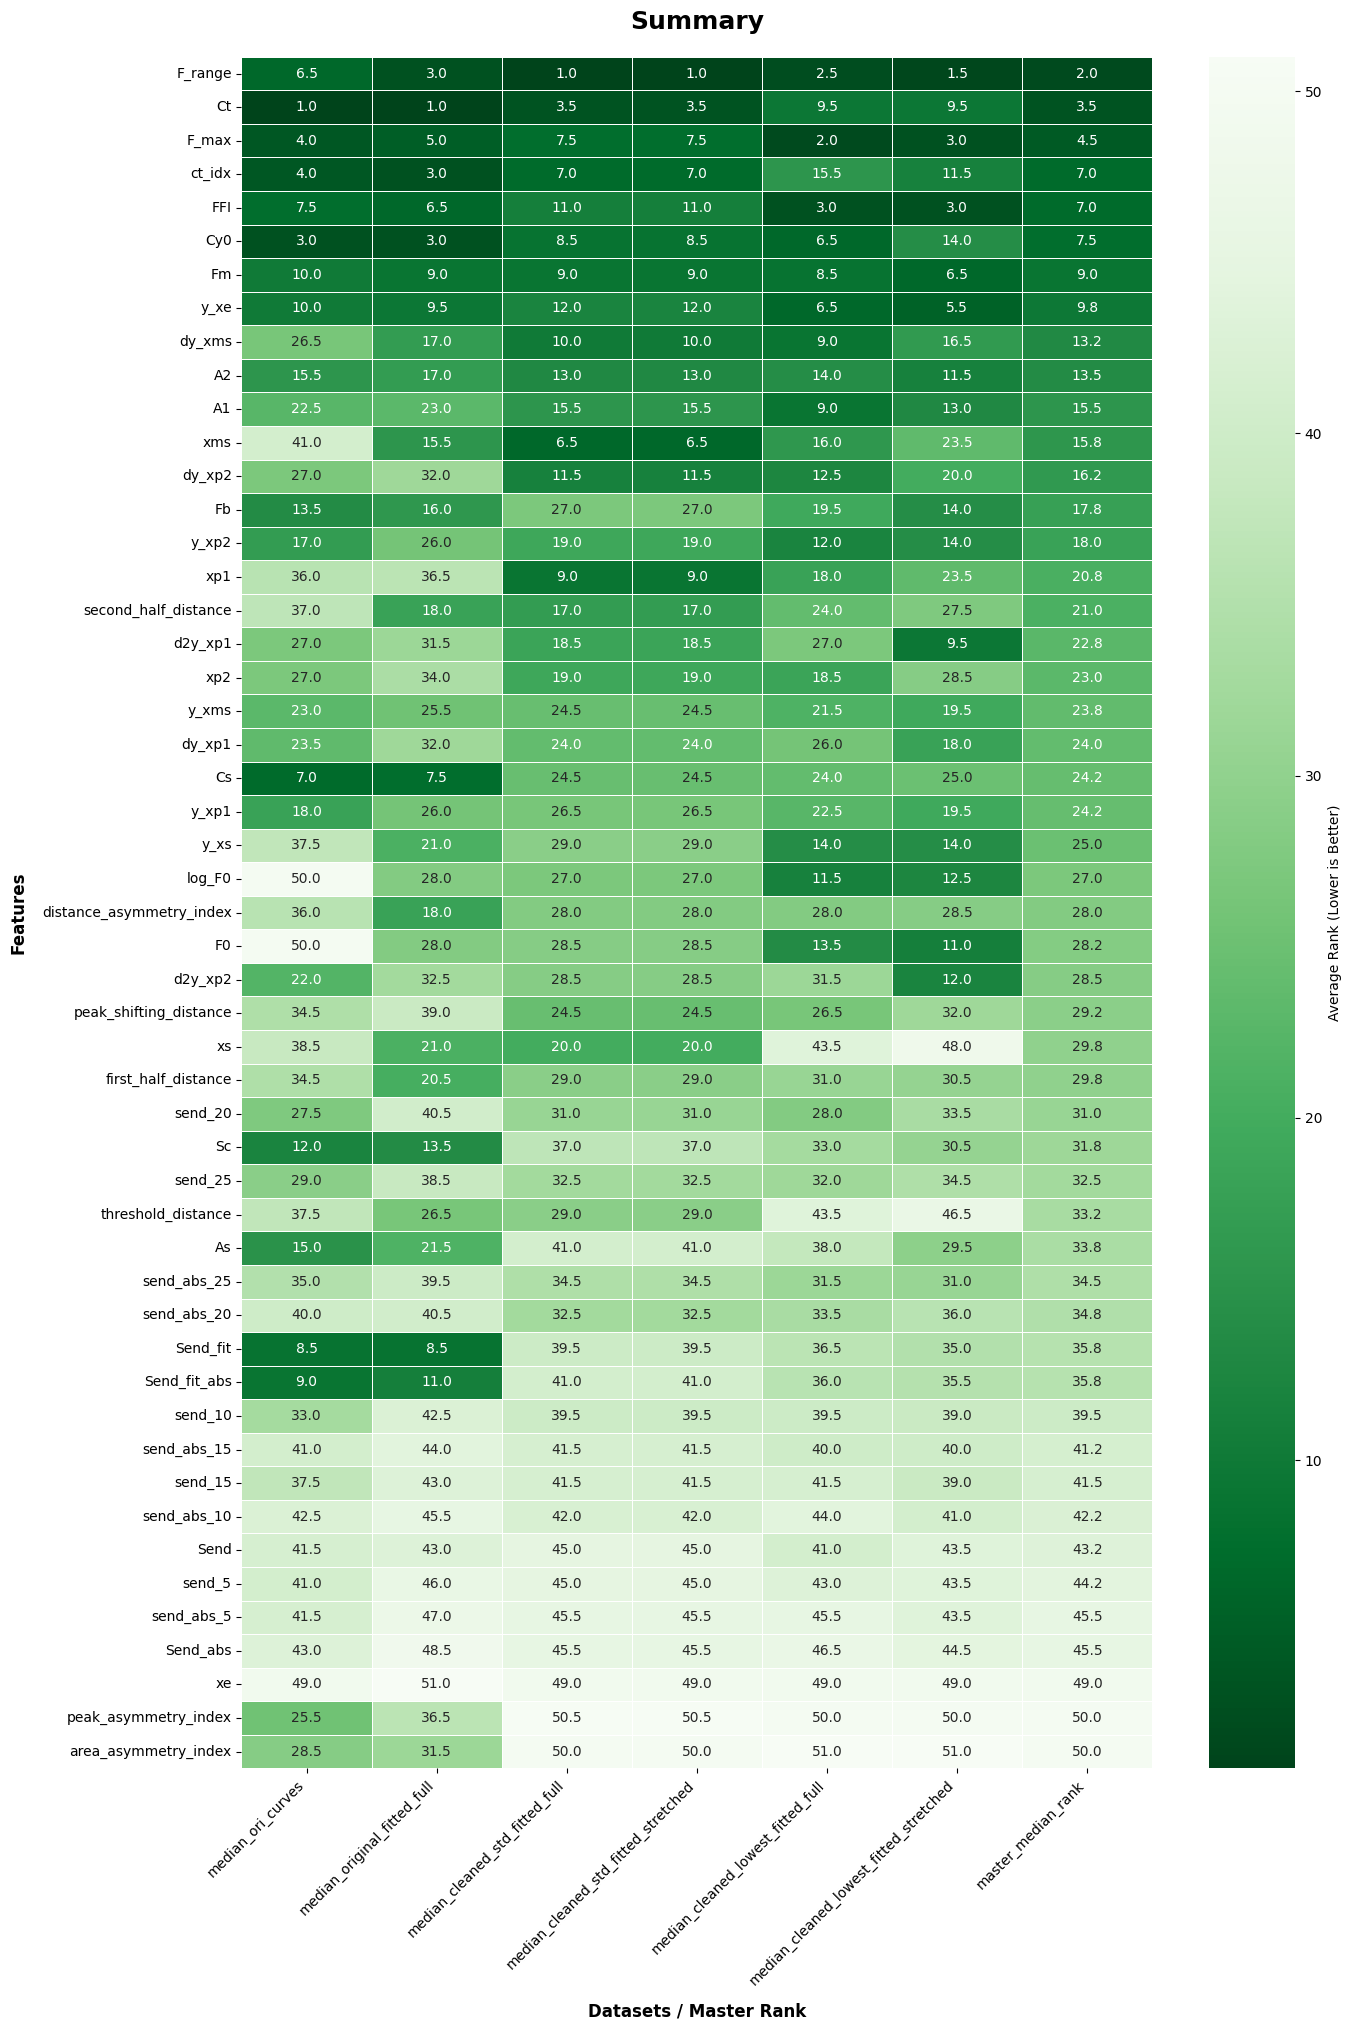

In [92]:
feature_importance_heatmap(final_cross_dataset_summary, "Summary")

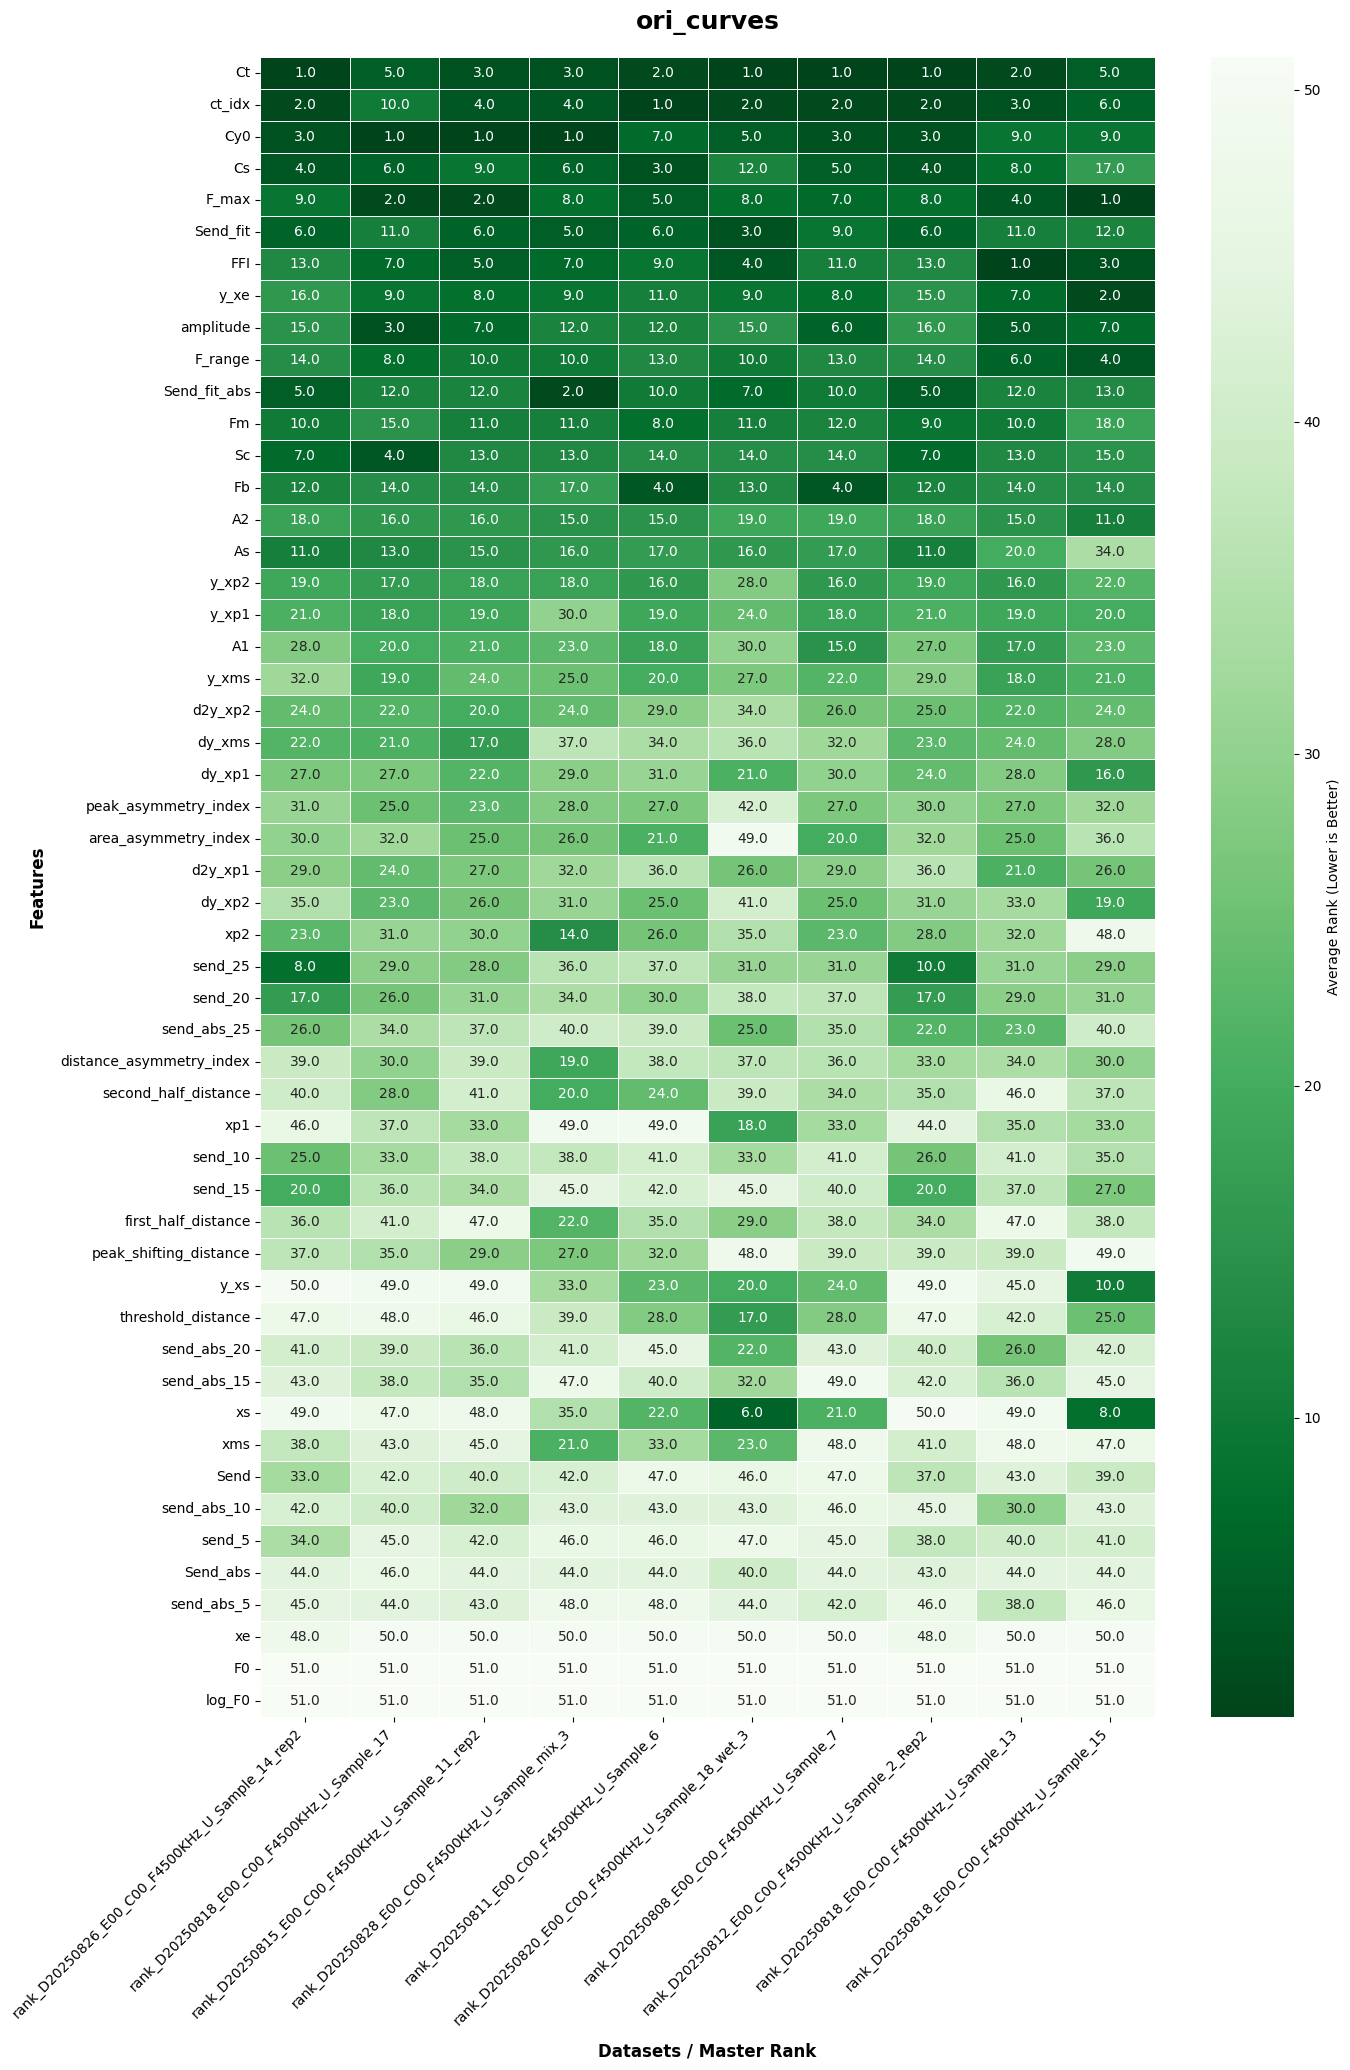

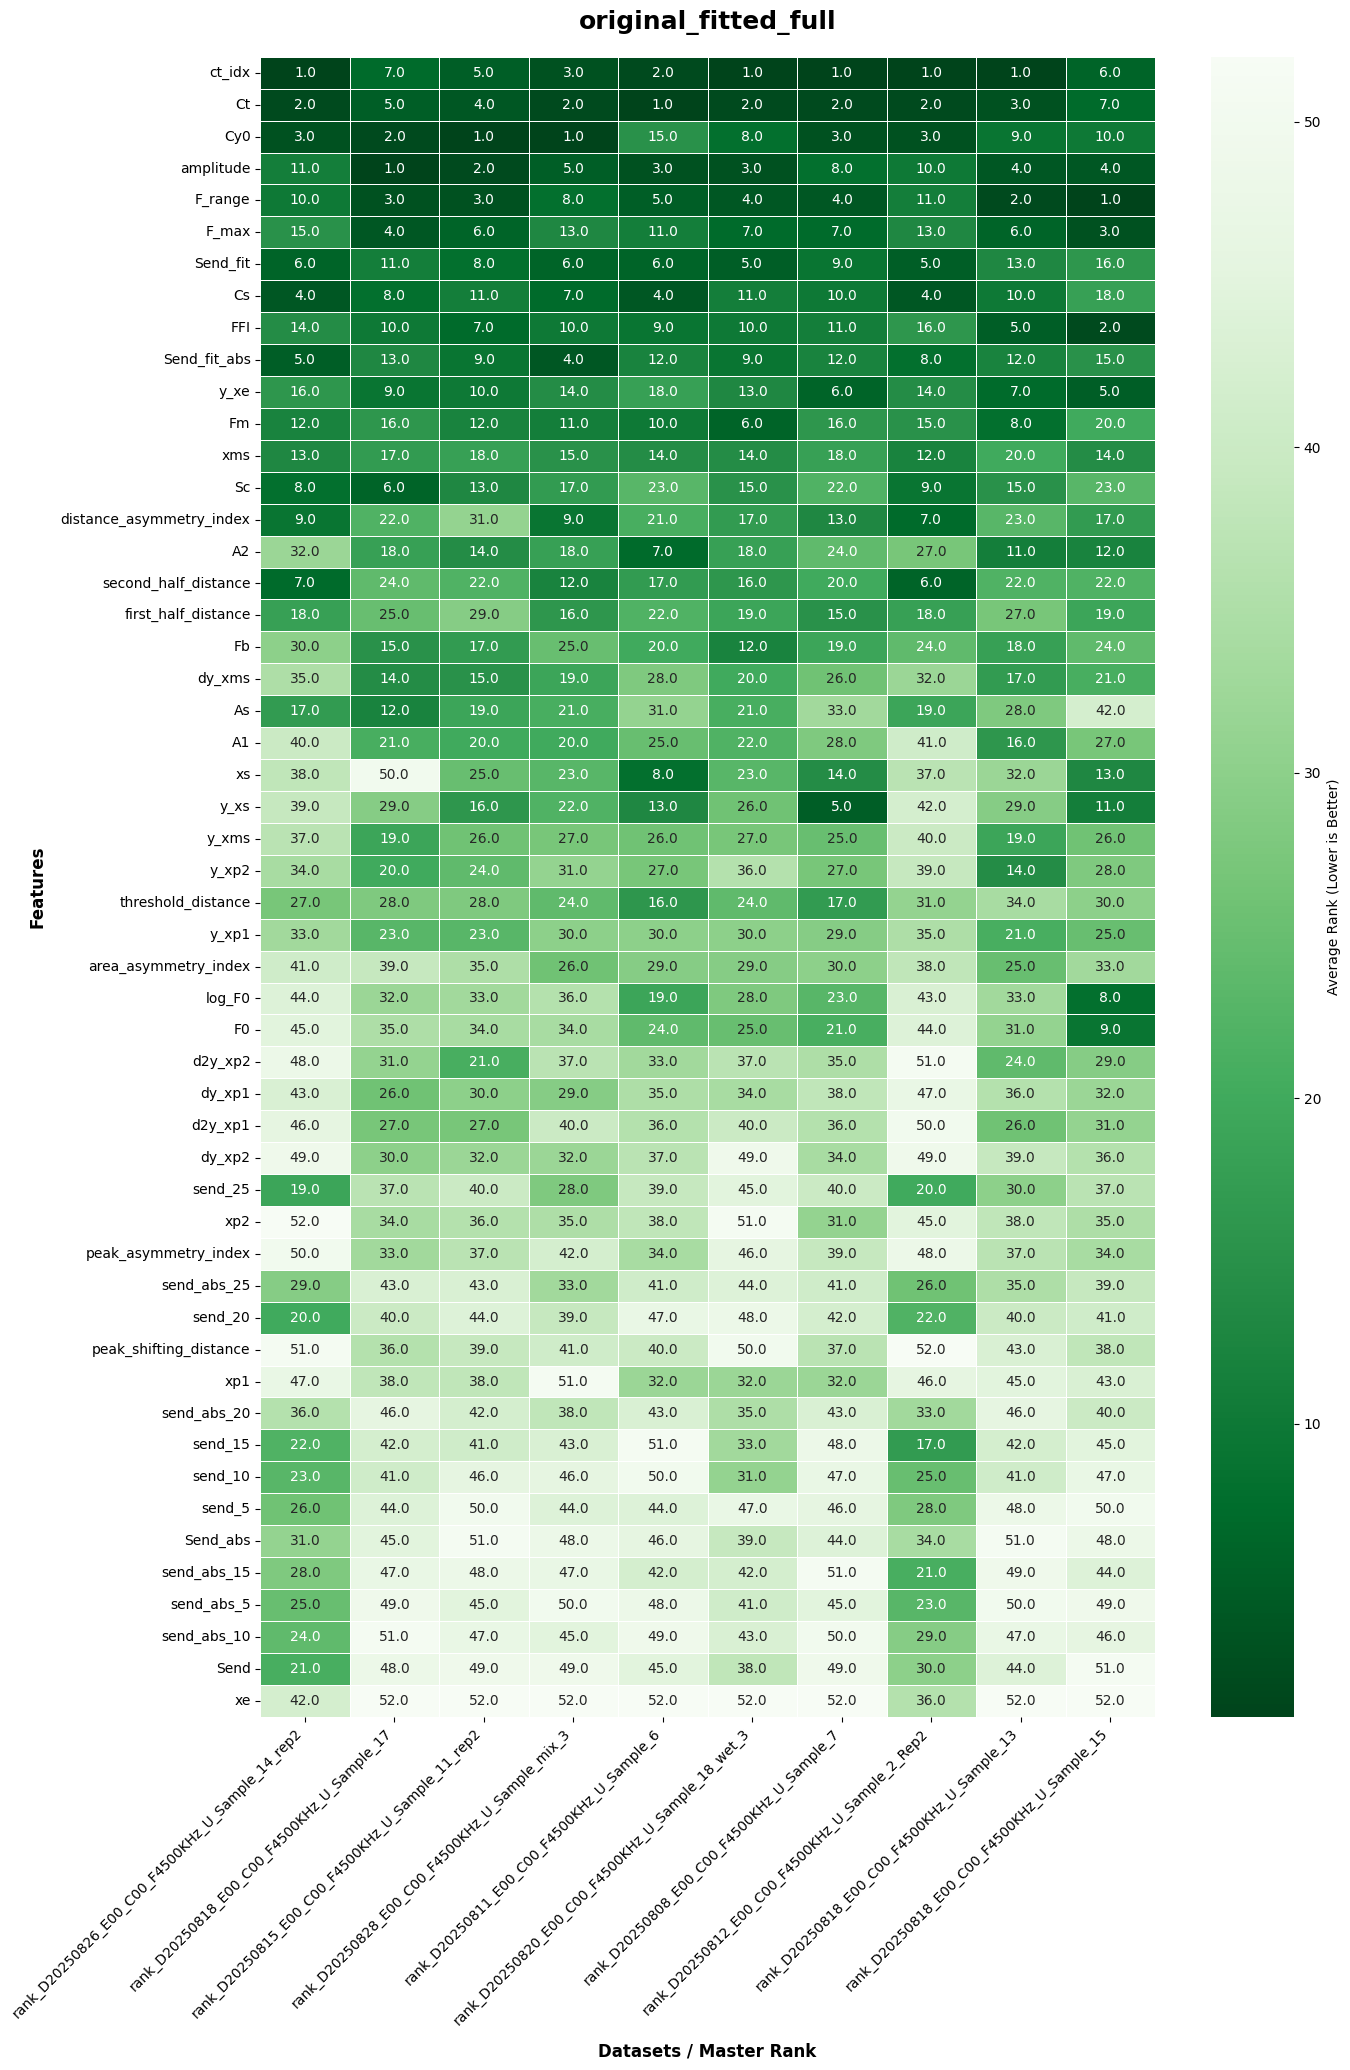

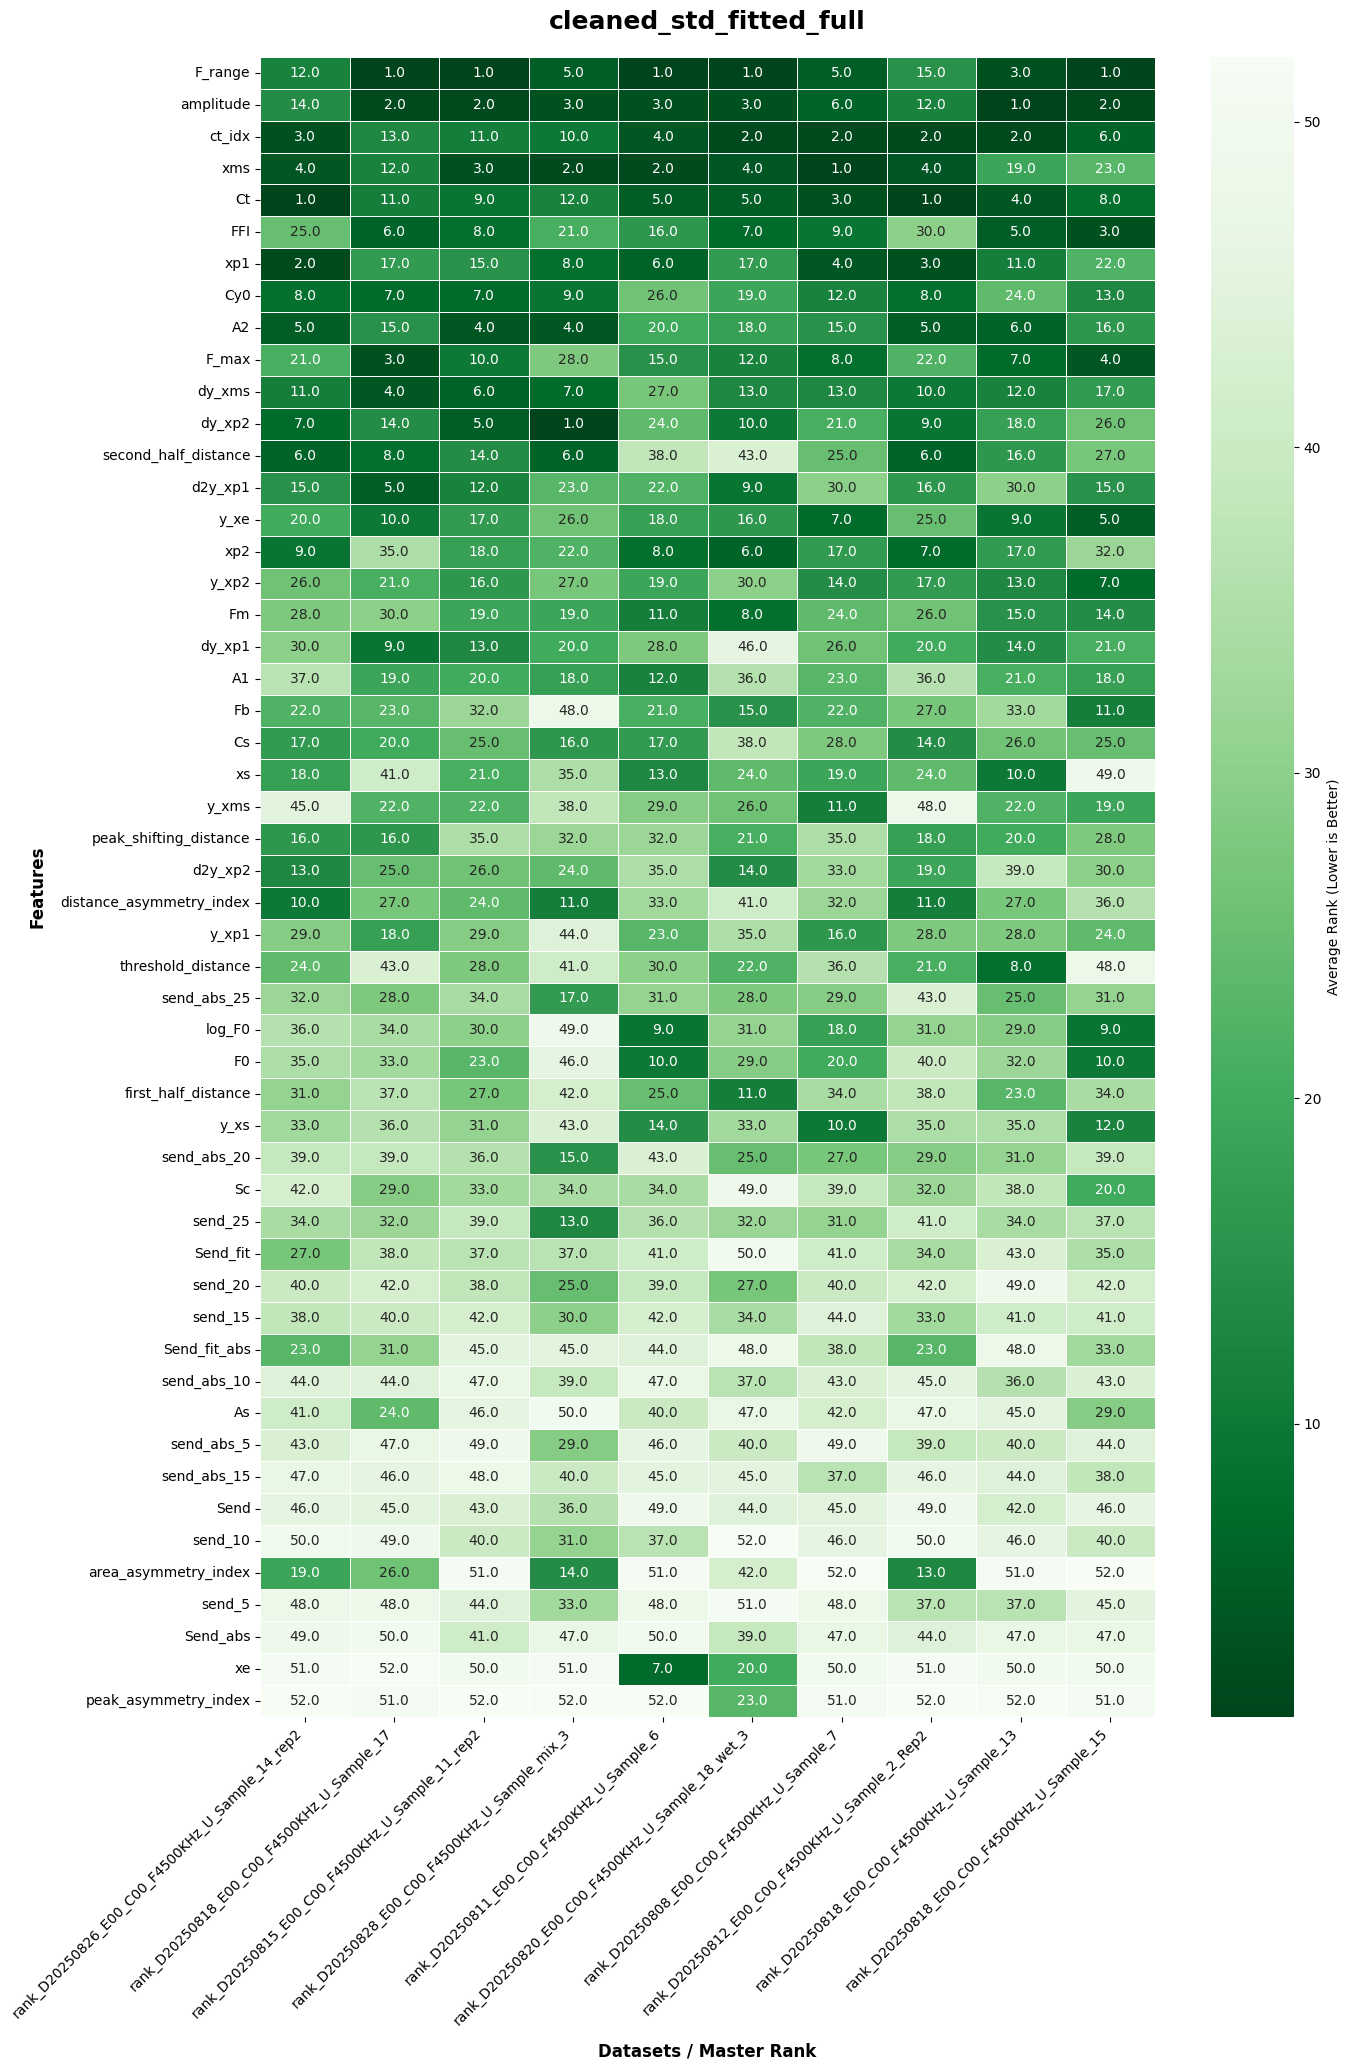

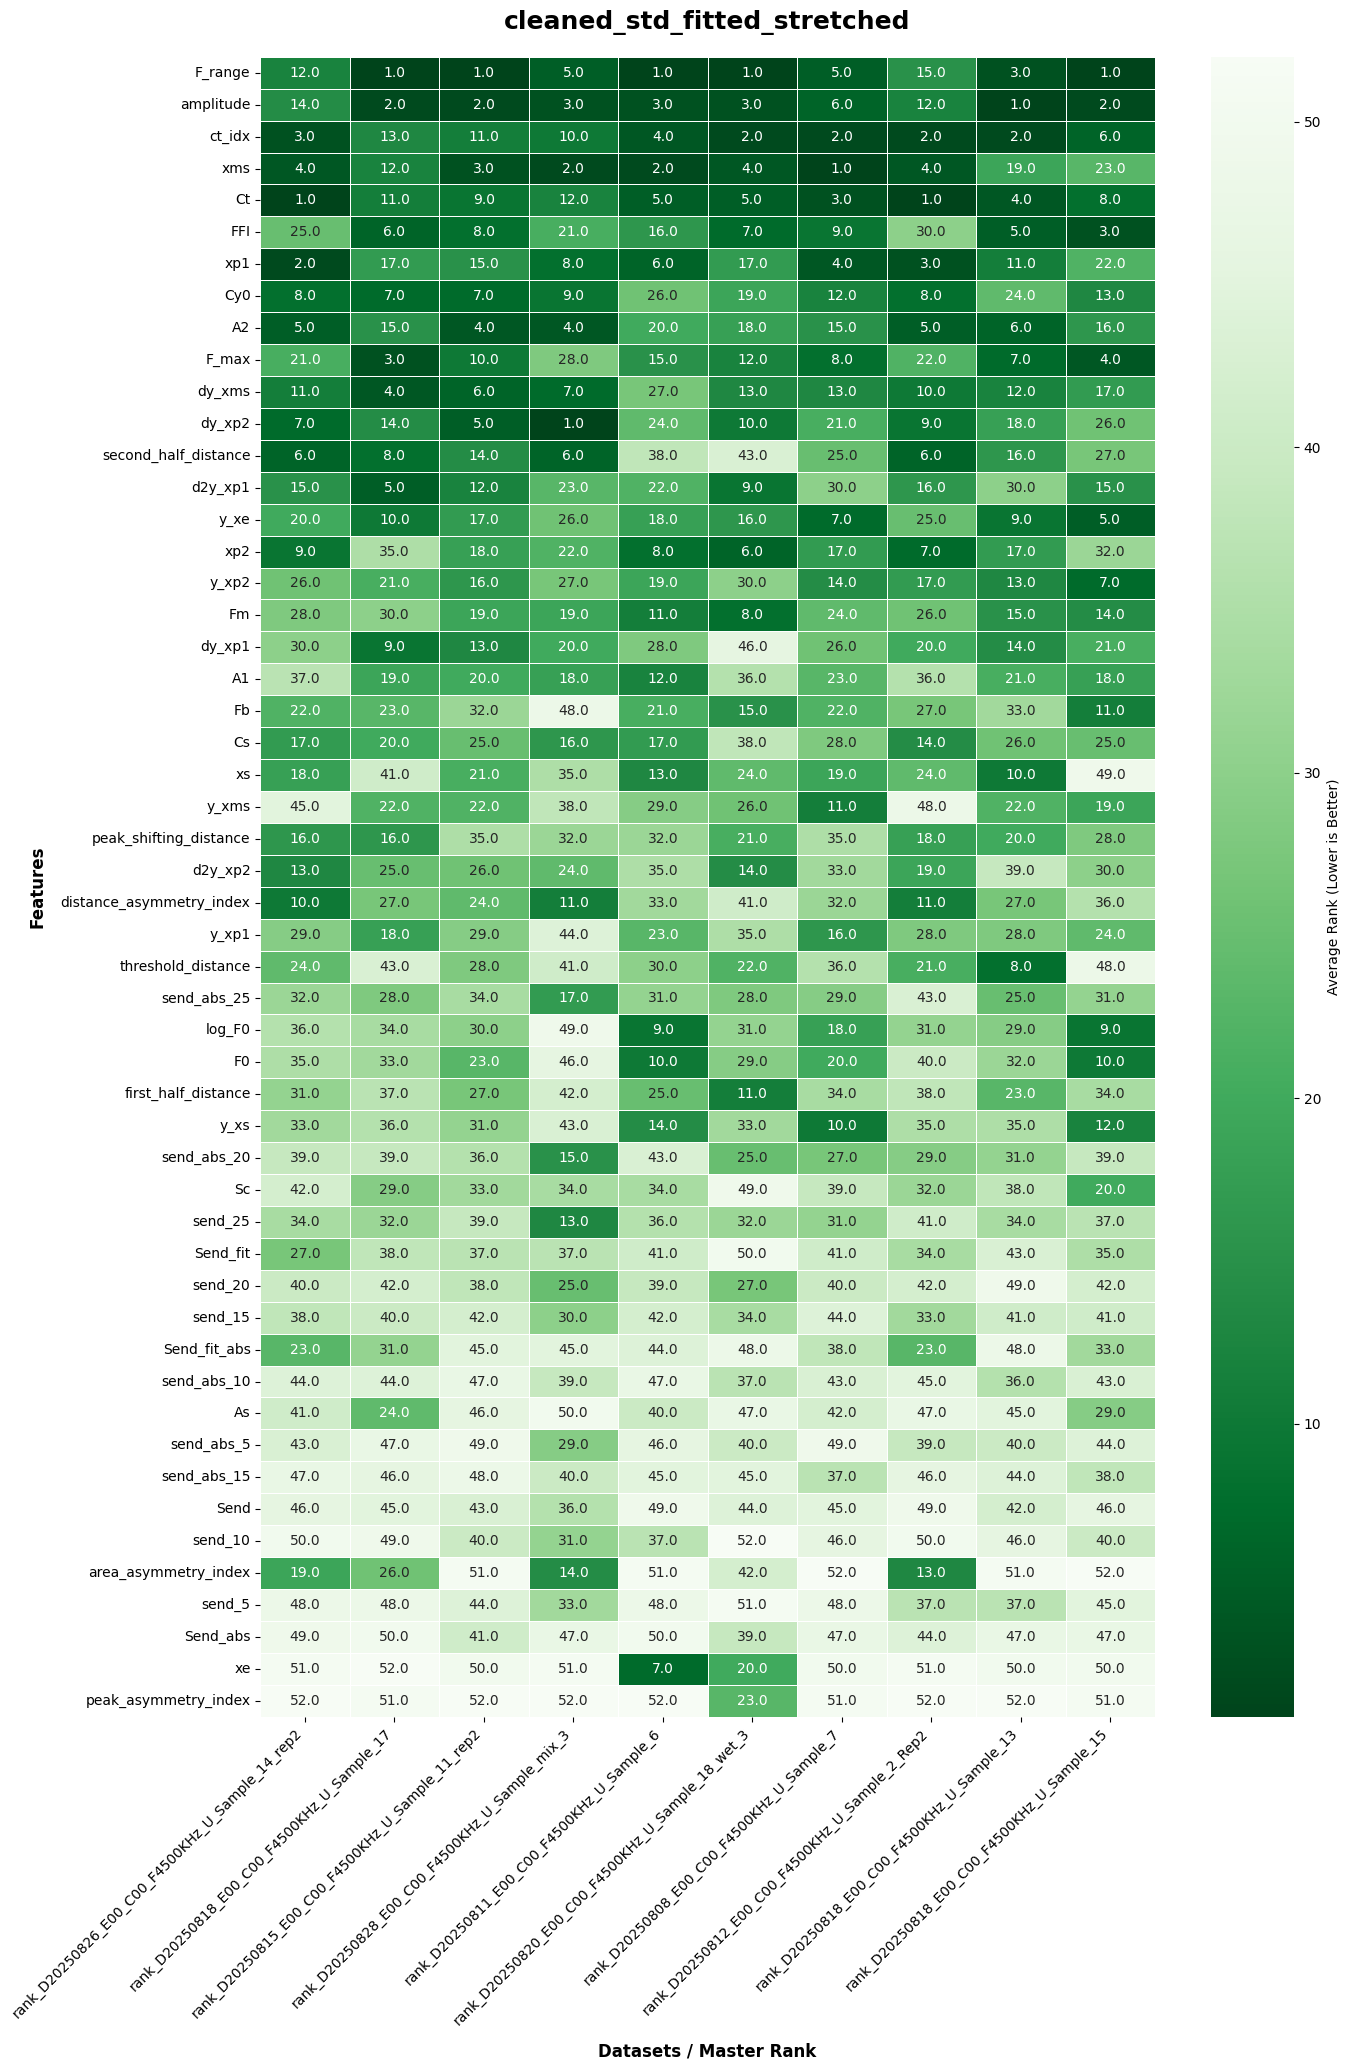

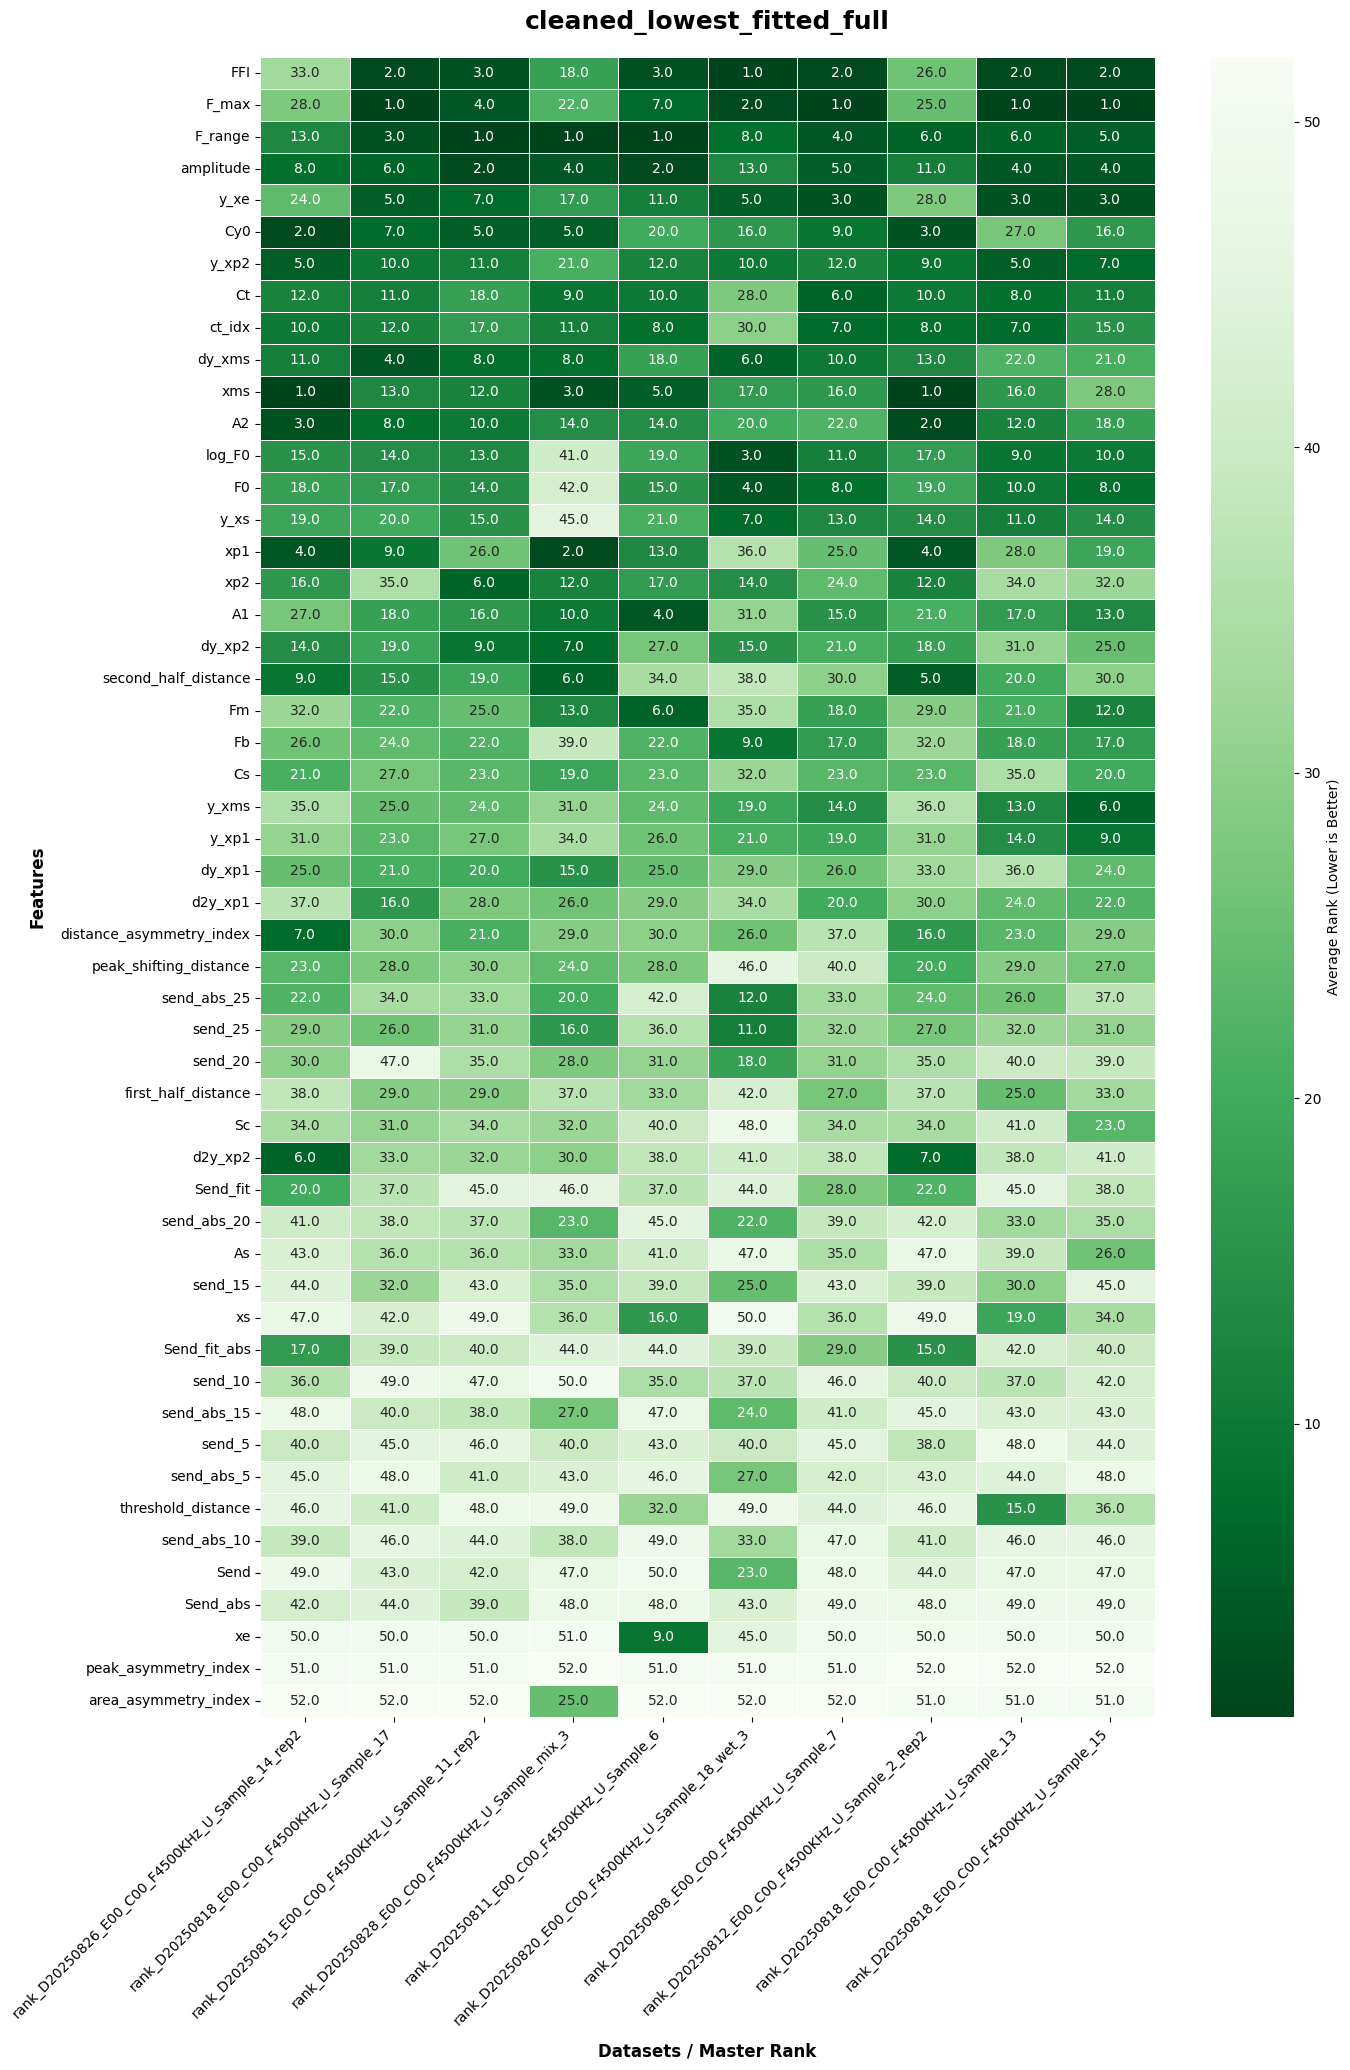

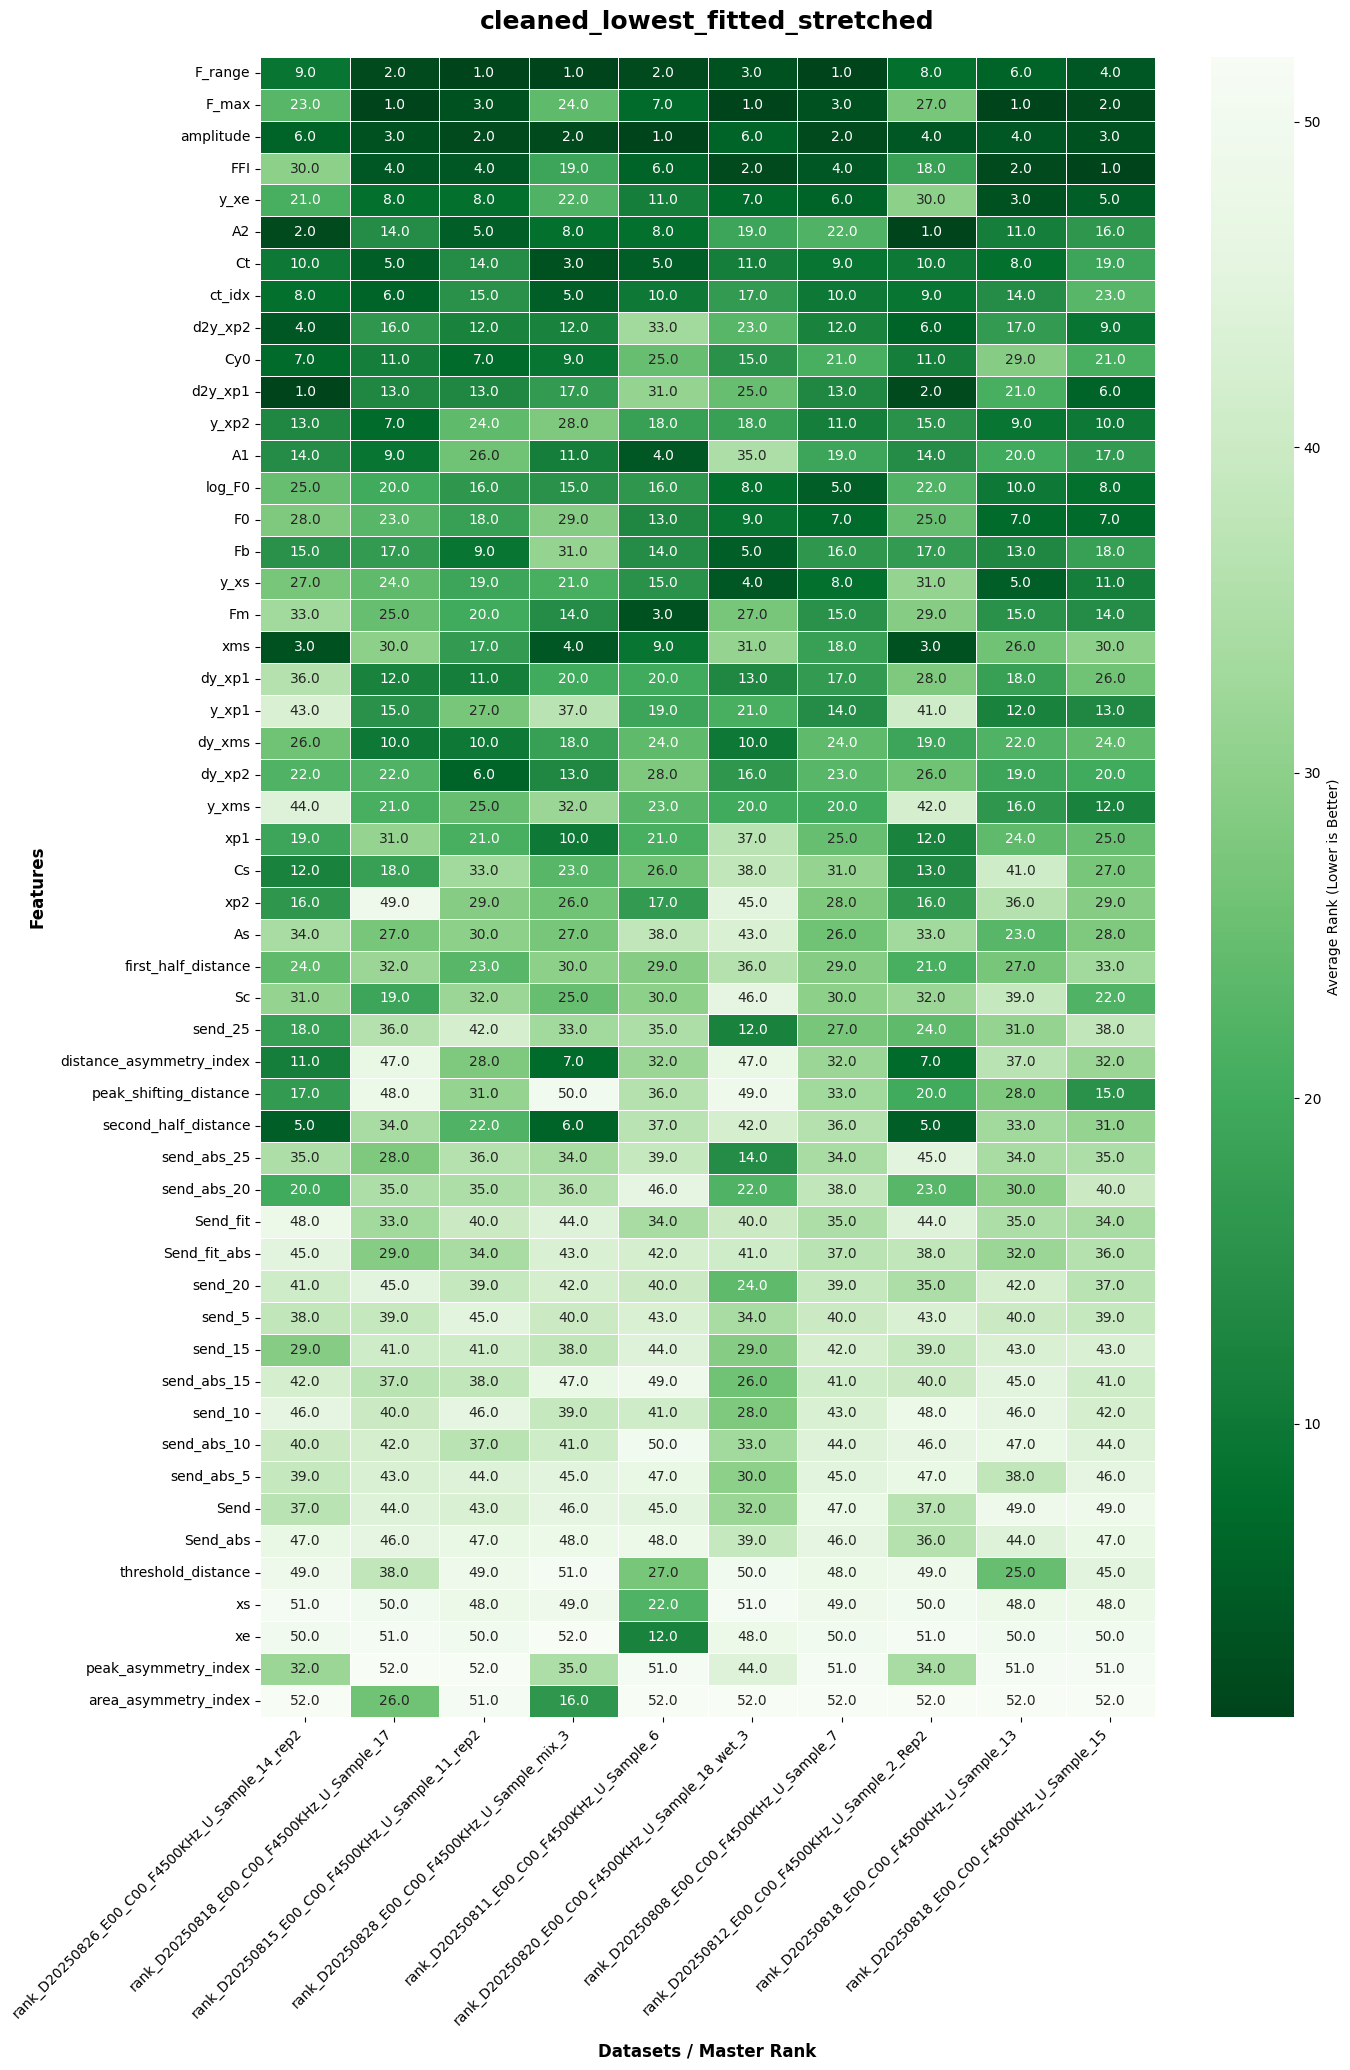

In [25]:
for name, df in feature_summary_dfs.items():
    feature_importance_heatmap(df.filter(regex="^rank|^feature$"), name)

,feature,rank_D20250826_E00_C00_F4500KHz_U_Sample_14_rep2,rank_D20250818_E00_C00_F4500KHz_U_Sample_17,rank_D20250815_E00_C00_F4500KHz_U_Sample_11_rep2,rank_D20250828_E00_C00_F4500KHz_U_Sample_mix_3,rank_D20250811_E00_C00_F4500KHz_U_Sample_6,rank_D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3,rank_D20250808_E00_C00_F4500KHz_U_Sample_7,rank_D20250812_E00_C00_F4500KHz_U_Sample_2_Rep2,rank_D20250818_E00_C00_F4500KHz_U_Sample_13,rank_D20250818_E00_C00_F4500KHz_U_Sample_15
0,Ct,1.0,7.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,5.0
1,Cy0,3.0,1.0,1.0,2.0,6.0,3.0,3.0,1.0,8.0,8.0
2,F_max,8.0,2.0,3.0,7.0,4.0,4.0,4.0,8.0,3.0,1.0
3,ct_idx,2.0,8.0,4.0,4.0,2.0,2.0,2.0,4.0,4.0,6.0
4,F_range,13.0,4.0,6.0,9.0,11.0,6.0,7.0,10.0,2.0,3.0
5,Cs,4.0,3.0,9.0,6.0,3.0,11.0,8.0,5.0,9.0,17.0
6,FFI,11.0,5.0,7.0,8.0,10.0,9.0,6.0,13.0,5.0,2.0
7,Send_fit,5.0,11.0,11.0,3.0,7.0,7.0,10.0,7.0,10.0,11.0
8,Send_fit_abs,6.0,9.0,10.0,5.0,9.0,5.0,11.0,9.0,11.0,13.0
9,Fm,10.0,12.0,5.0,10.0,5.0,10.0,12.0,3.0,7.0,12.0


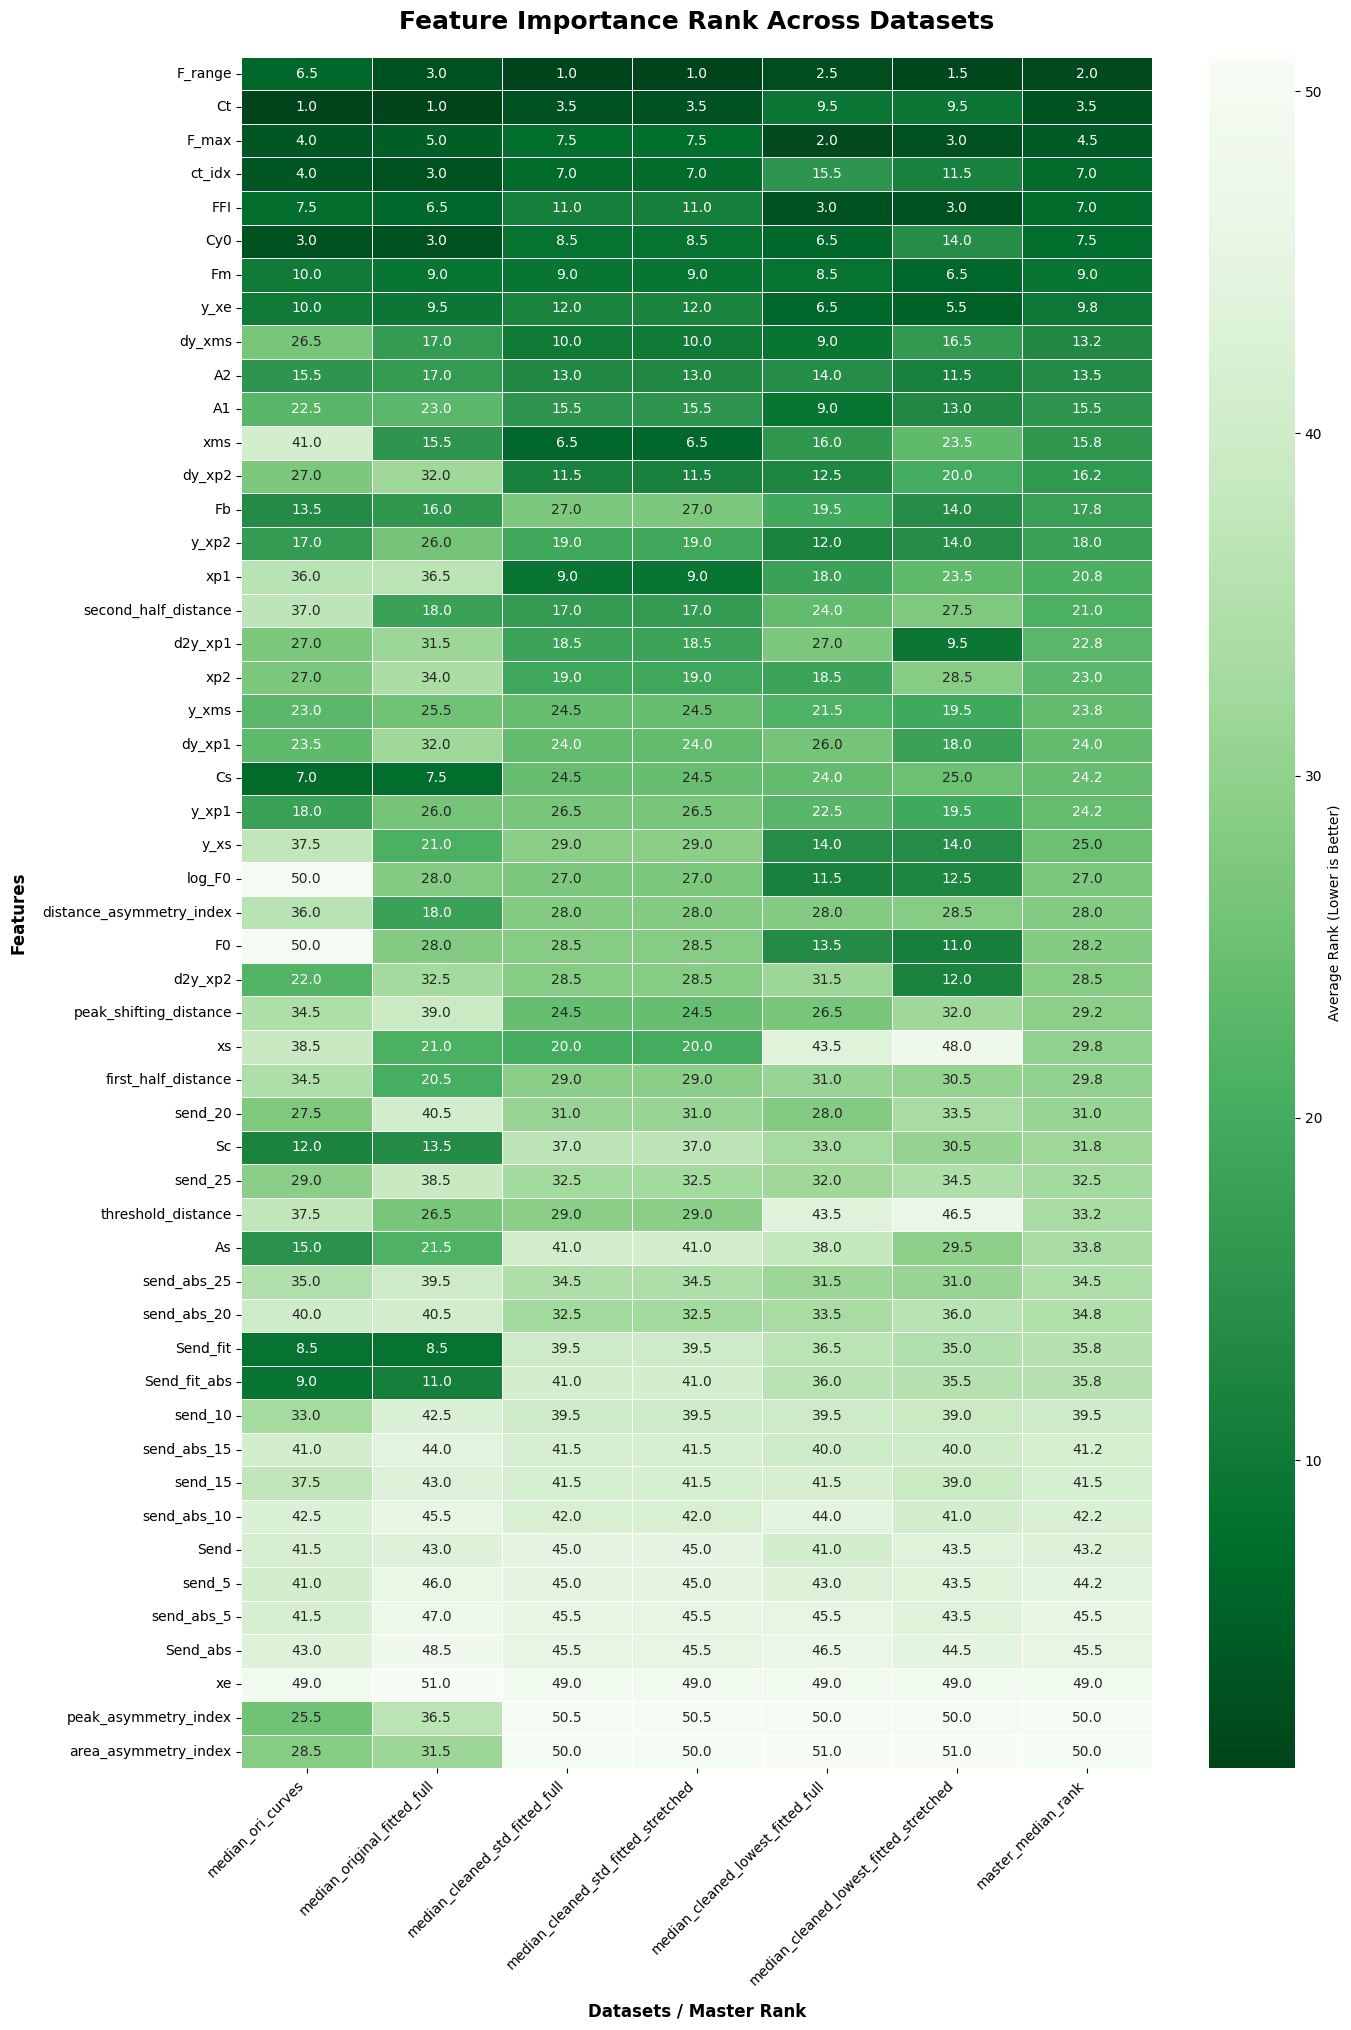